In [37]:
import scanpy as sc
import matplotlib.pyplot as plt
import omicverse as ov
import numpy as np
import pandas as pd
from utils.utils import *

In [38]:
ov.style(font_path='Arial')

🔬 Starting plot initialization...
Failed to download Arial font: HTTPSConnectionPool(host='github.com', port=443): Max retries exceeded with url: /kavin808/arial.ttf/raw/refs/heads/master/arial.ttf (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7f33f2e37bb0>: Failed to establish a new connection: [Errno 111] Connection refused'))
Continuing with default font settings...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA GeForce RTX 3060
      Memory: 12.0 GB | Compute: 8.6
✅ plot_set complete.



In [39]:
adata = sc.read_h5ad('integrate_h5ad/islet_beta_PanNET_intergtated.h5ad')
donor_idx = adata.obs['batch'].value_counts()  
donor_keep = donor_idx[donor_idx > 200].index.to_list()
adata_sub = adata[adata.obs['batch'].isin(donor_keep)].copy()

In [40]:
sample_map =  {
    "251030T": "P1",
    "251211T" : "P2",
    "251224T" : "P3",
    "260119T" : "P4",
    "260129T" : "P5"
}
adata_sub.obs['donor'] = (
    adata_sub.obs['batch']
    .map(sample_map)
    .fillna(adata_sub.obs['batch'])
)

... storing 'donor' as categorical


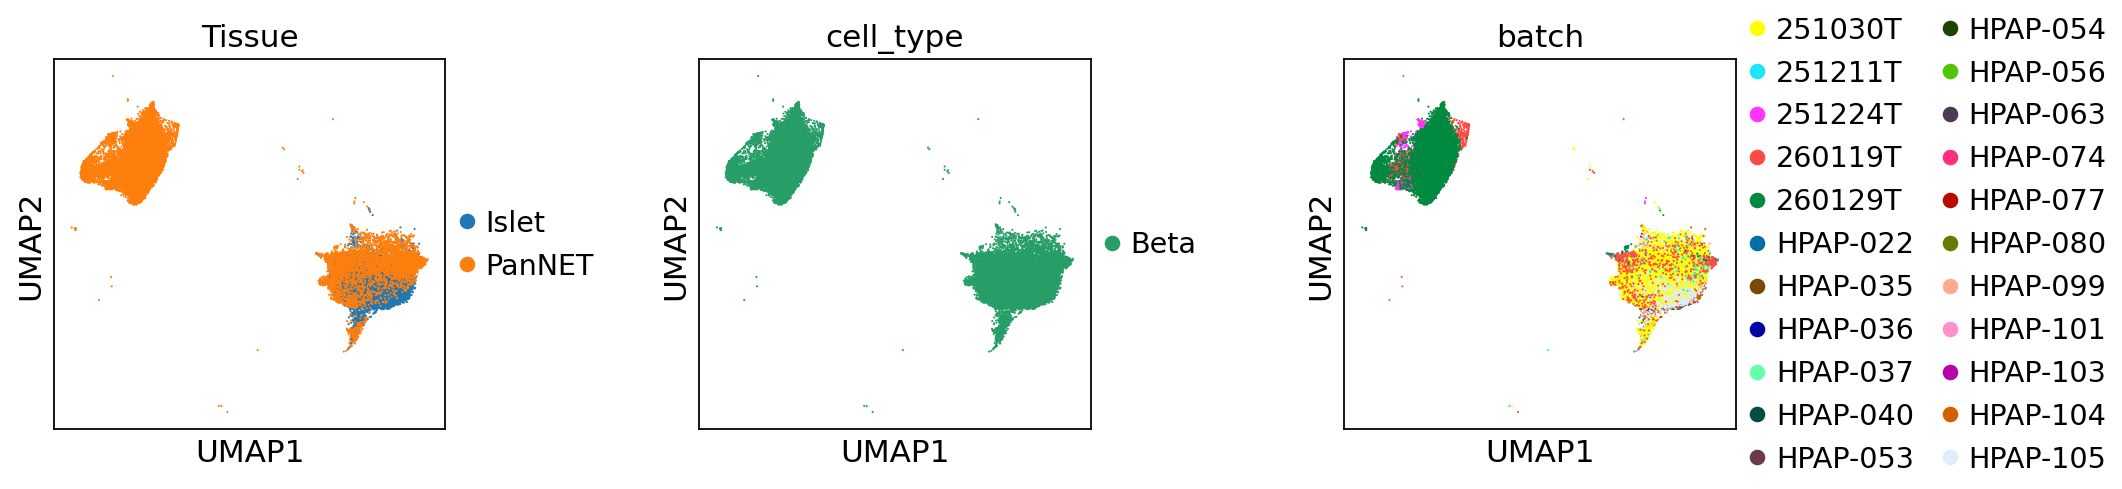

In [41]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(adata_sub,color=['Tissue','cell_type','batch'],wspace=0.5)

In [42]:
adata_sub = run_umap(adata_sub,nfeatures=500,batch_key='batch',n_neighbors=30,min_dist=0.3)

2026-05-01 14:23:23,862 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-01 14:23:23 - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-01 14:23:27,600 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-01 14:23:27 - INFO - sklearn.KMeans initialization complete.
2026-05-01 14:23:27,764 - harmonypy - INFO - Iteration 1 of 20
2026-05-01 14:23:27 - INFO - Iteration 1 of 20
2026-05-01 14:23:42,643 - harmonypy - INFO - Iteration 2 of 20
2026-05-01 14:23:42 - INFO - Iteration 2 of 20
2026-05-01 14:23:55,342 - harmonypy - INFO - Iteration 3 of 20
2026-05-01 14:23:55 - INFO - Iteration 3 of 20
2026-05-01 14:24:10,369 - harmonypy - INFO - Converged after 3 iterations
2026-05-01 14:24:10 - INFO - Converged after 3 iterations


In [43]:
sc.tl.leiden(adata_sub,flavor='igraph',resolution=2)

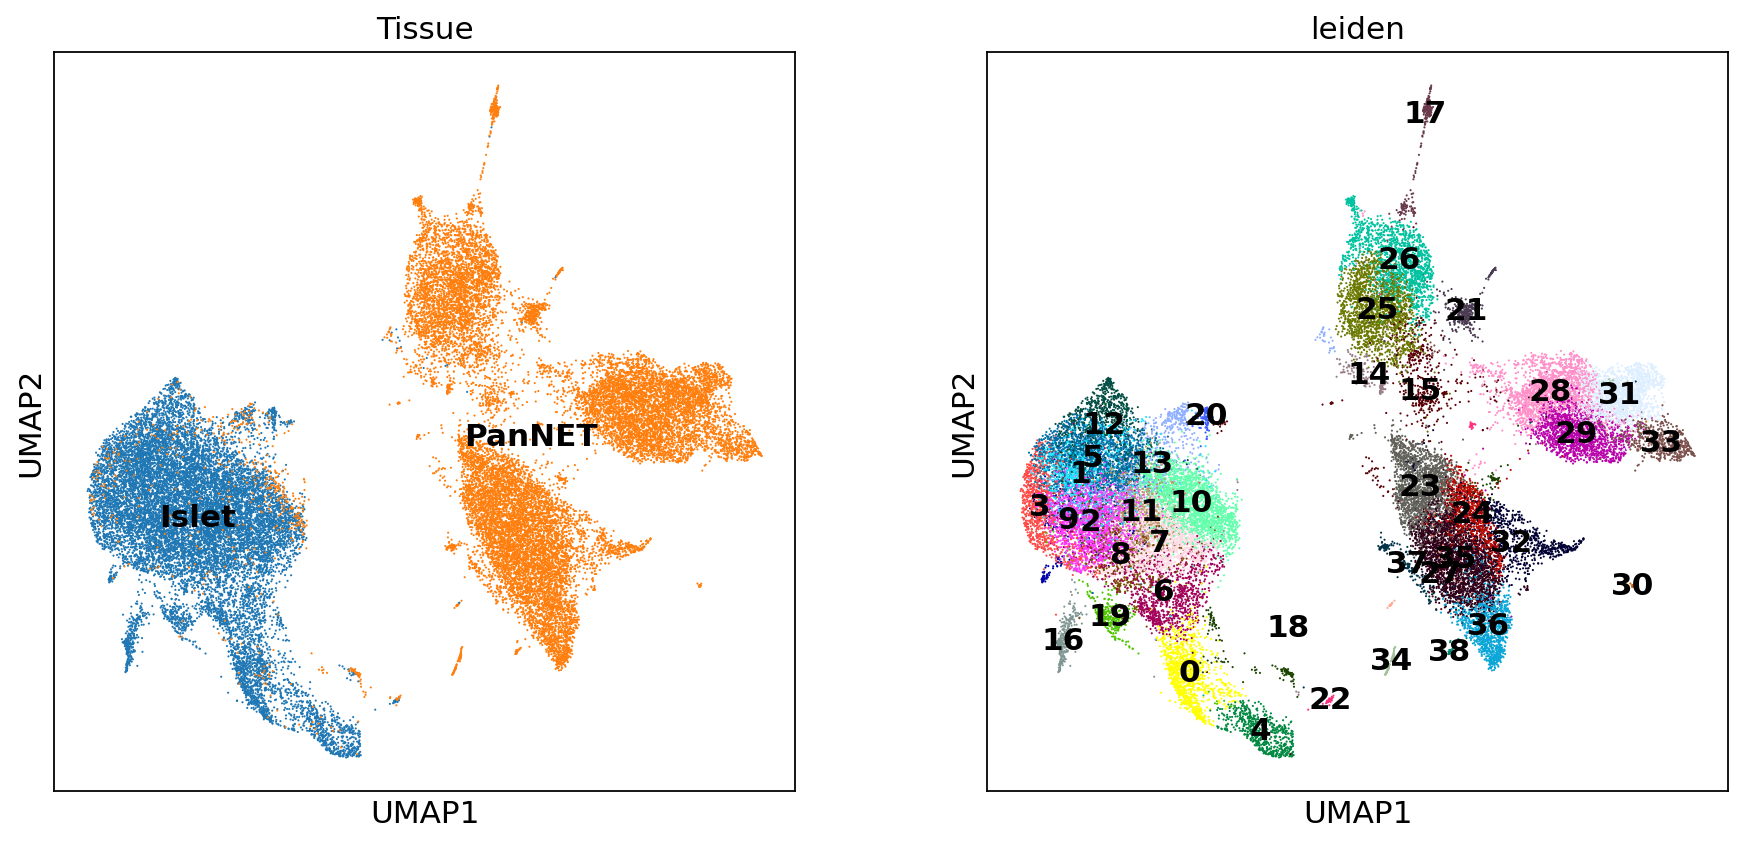

In [45]:
with plt.rc_context({'figure.figsize': (6, 6)}):
    sc.pl.umap(adata_sub,color=['Tissue','leiden'],legend_loc='on data')

In [46]:
adata_sub_final = adata_sub[~adata_sub.obs['leiden'].isin(['17','30','34'])].copy()
adata_sub_final = adata_sub_final.raw.to_adata()

In [52]:
adata_sub_final.X.max()

158798.0

In [53]:
adata_sub_final = run_umap(adata_sub_final,nfeatures=500,batch_key='batch',n_neighbors=30,min_dist=0.3)

2026-05-01 14:28:51,807 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-01 14:28:51 - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-01 14:28:56,706 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-01 14:28:56 - INFO - sklearn.KMeans initialization complete.
2026-05-01 14:28:56,878 - harmonypy - INFO - Iteration 1 of 20
2026-05-01 14:28:56 - INFO - Iteration 1 of 20
2026-05-01 14:29:14,743 - harmonypy - INFO - Iteration 2 of 20
2026-05-01 14:29:14 - INFO - Iteration 2 of 20
2026-05-01 14:29:30,199 - harmonypy - INFO - Iteration 3 of 20
2026-05-01 14:29:30 - INFO - Iteration 3 of 20
2026-05-01 14:29:45,608 - harmonypy - INFO - Converged after 3 iterations
2026-05-01 14:29:45 - INFO - Converged after 3 iterations


In [56]:
sc.tl.umap(adata_sub_final,min_dist=0.5)

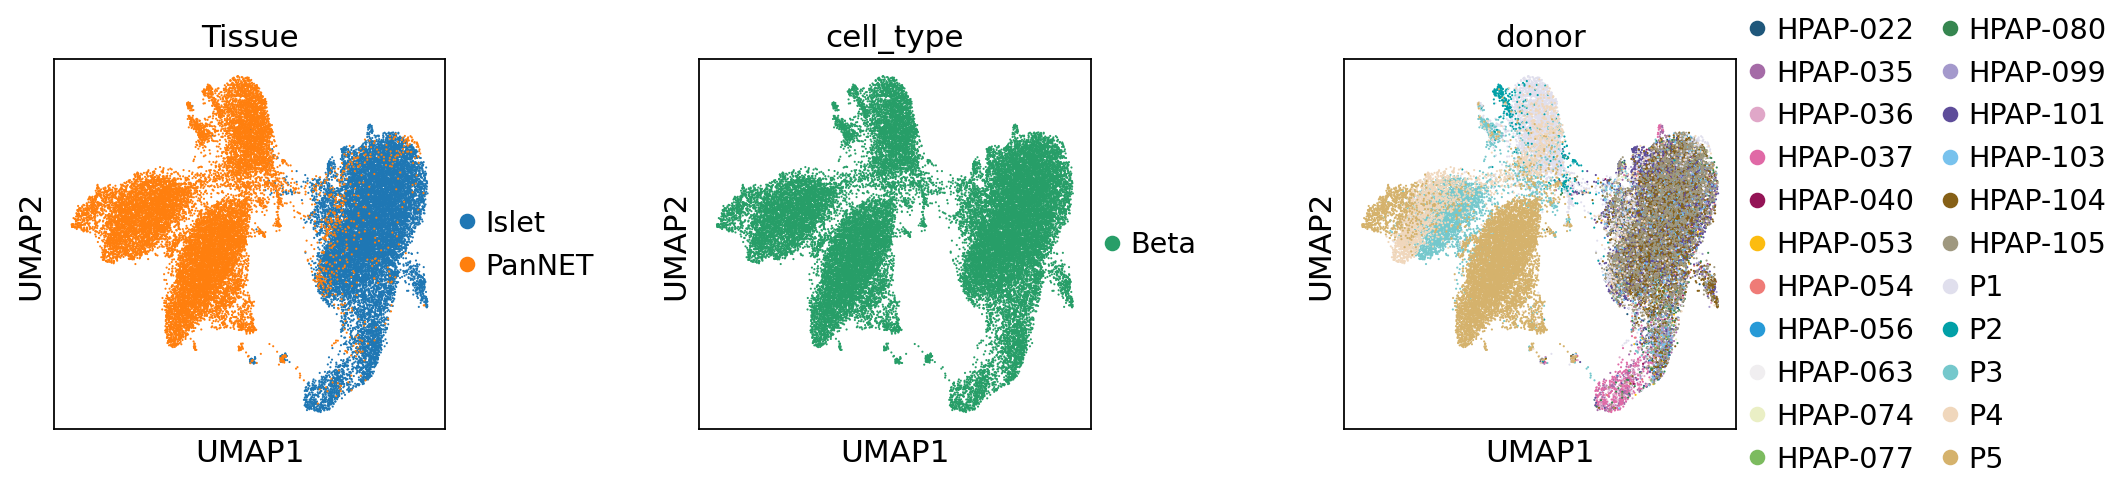

In [57]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(adata_sub_final,color=['Tissue','cell_type','donor'],wspace=0.5)

In [59]:
adata_sub_final = adata_sub_final.raw.to_adata()

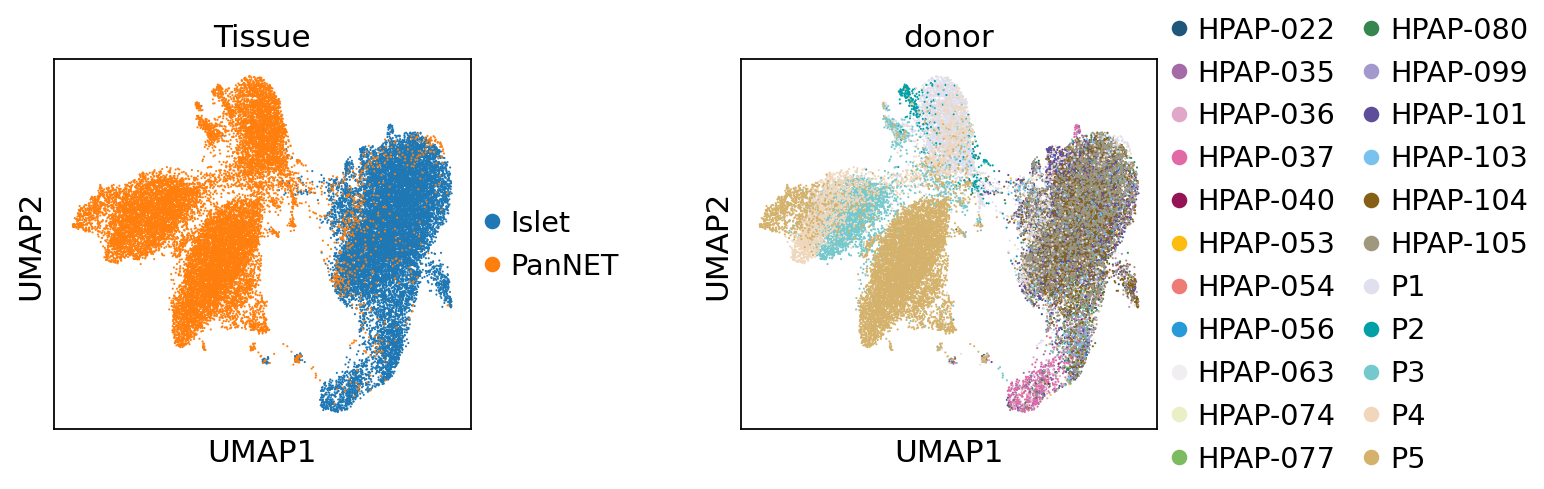

In [62]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(adata_sub_final,color=['Tissue','donor'],wspace=0.5,save = 'Figure_UMAP_intergrate.pdf')

In [58]:
adata_sub_final.write_h5ad('h5ad/islet_beta_PanNET_intergtated_final.h5ad')

In [111]:
go_gene = pd.read_excel('Figure2/Table/Main_GO_gene.xlsx')

In [112]:
function_gene_dict = go_gene.groupby("main_function")["Gene"].apply(list).to_dict()

In [113]:
go_gene['main_function'].value_counts()

main_function
Synapse              341
secretory_granule    230
translation           89
DNA_repair            59
Name: count, dtype: int64

In [74]:
adata_sub_final.raw = adata_sub_final.copy()
sc.pp.normalize_total(adata_sub_final)
sc.pp.log1p(adata_sub_final)

In [114]:
geneset_names=go_gene['main_function'].value_counts().index.to_list()
ov.single.pathway_aucell(
    adata_sub_final,
    pathway_names=geneset_names,
    pathways_dict=function_gene_dict
)

100%|██████████| 32795/32795 [00:20<00:00, 1583.50it/s]


In [115]:
geneset_names

['Synapse', 'secretory_granule', 'translation', 'DNA_repair']

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


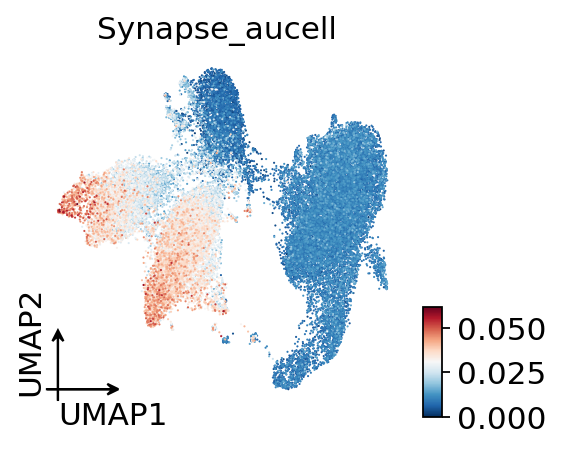

In [121]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    ov.pl.umap(adata_sub_final,color=f'{geneset_names[0]}_aucell',save = f'figures/Figure2_{geneset_names[0]}_gene_score.pdf')

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


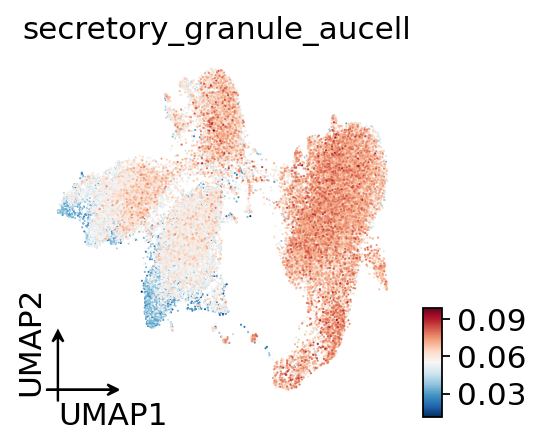

In [120]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    ov.pl.umap(adata_sub_final,color=f'{geneset_names[1]}_aucell',save = f'figures/Figure2_{geneset_names[1]}_gene_score.pdf')

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


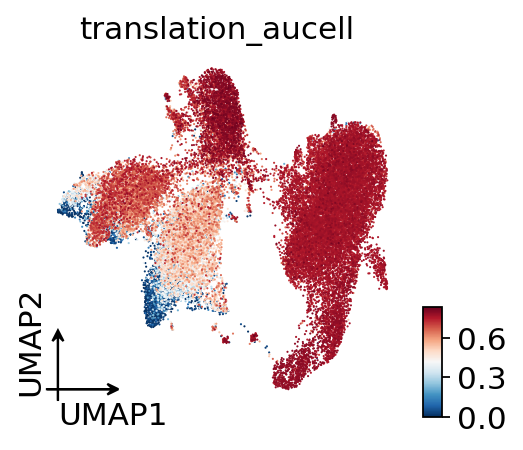

In [119]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    ov.pl.umap(adata_sub_final,color=f'{geneset_names[2]}_aucell',save = f'figures/Figure2_{geneset_names[2]}_gene_score.pdf')

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


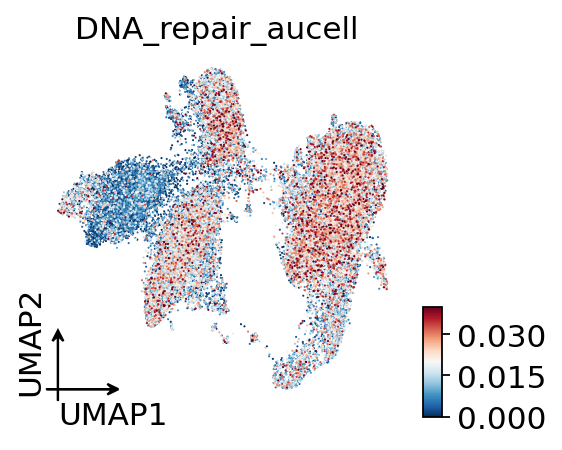

In [118]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    ov.pl.umap(adata_sub_final,color=f'{geneset_names[3]}_aucell',vmax = 0.04,save = f'figures/Figure2_{geneset_names[3]}_gene_score.pdf')

In [117]:
ov.pp.score_genes_cell_cycle(adata_sub_final,species='human')


╭─ SUMMARY: score_genes_cell_cycle ──────────────────────────────────╮
│  Duration: 2.7498s                                                 │
│  Shape:    32,795 x 31,316 (Unchanged)                             │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ G2M_score (float)                                    │
│           │ ✚ S_score (float)                                      │
│           │ ✚ phase (str)                                          │
│                                                                    │
│  ● UNS    │ ✚ status                                               │
│           │ ✚ status_args                                          │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


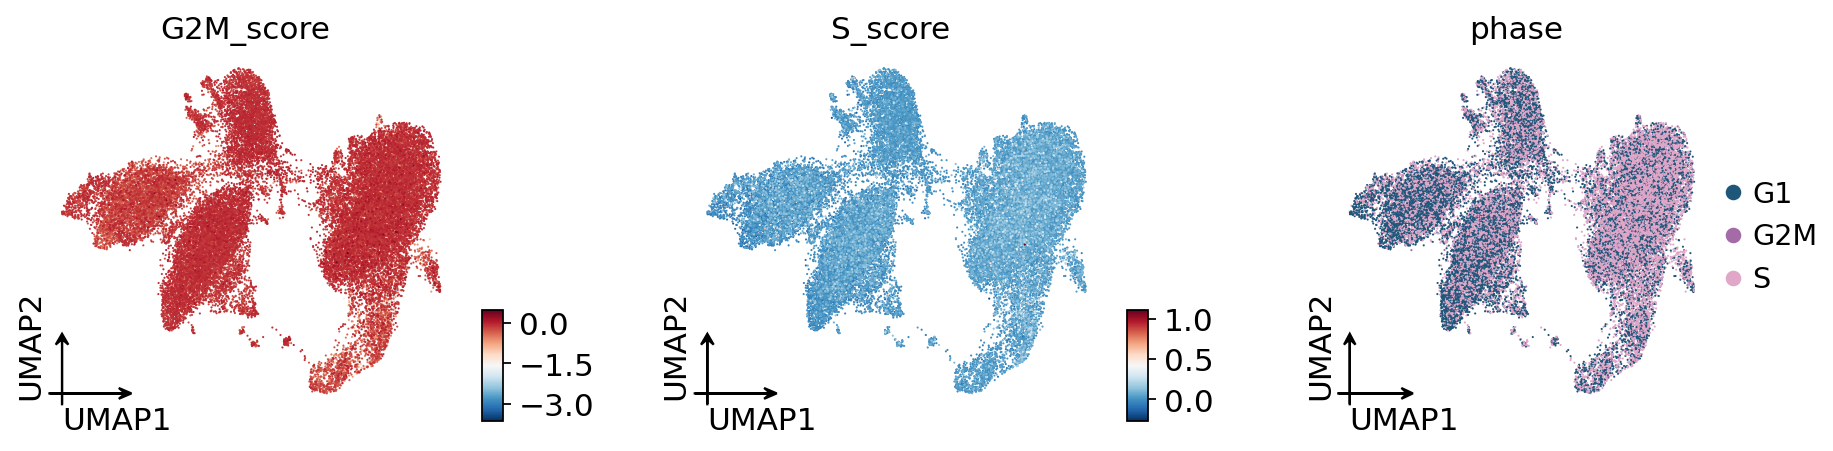

In [123]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    ov.pl.umap(adata_sub_final,color=['G2M_score','S_score','phase'],wspace = 0.5)

In [124]:
adata_sub_final.obs.to_csv('./Figure2/Table/figure2_gene_score.csv')

In [127]:
adata_sub_final.X.max()

9.333149322894432

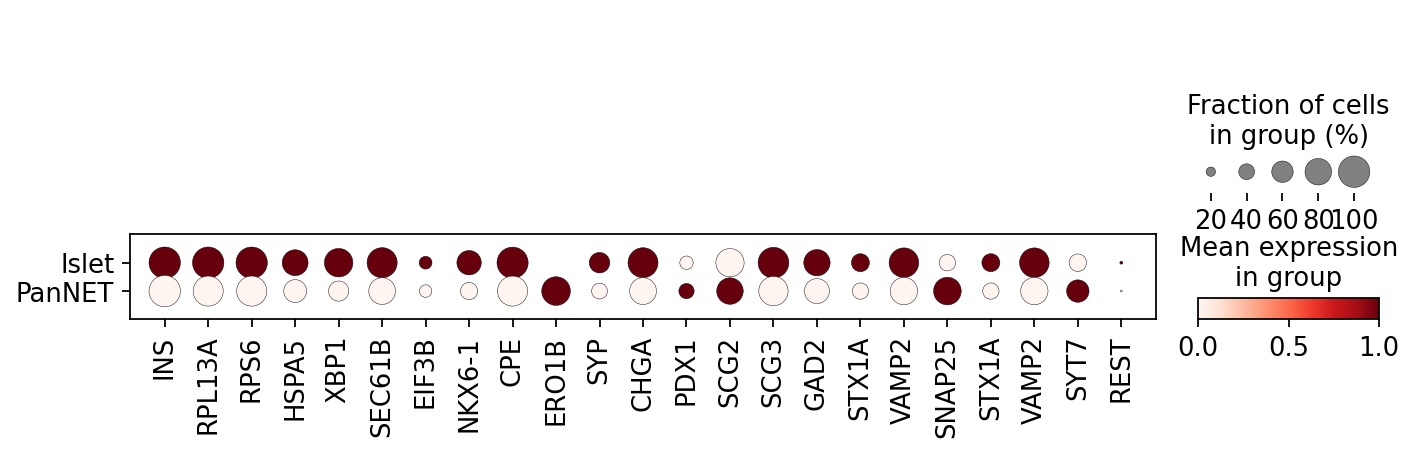

In [141]:
key_gene = ['INS','RPL13A','RPS6','HSPA5','XBP1','SEC61B','EIF3B','NKX6-1','CPE','ERO1B','SYP','CHGA',
            'PDX1','SCG2','SCG3','GAD2','STX1A','VAMP2','SNAP25','STX1A','VAMP2','SYT7','REST']
sc.pl.dotplot(adata_sub_final,var_names=key_gene,groupby='Tissue',standard_scale='var')

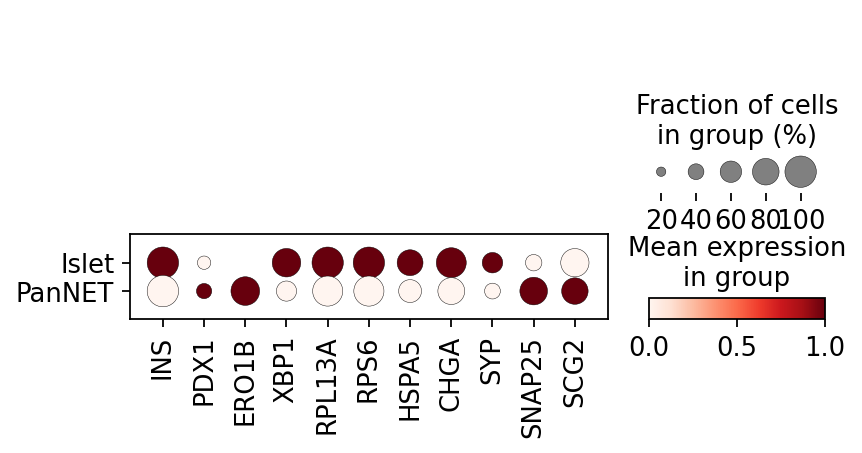

In [151]:
key_gene2 = [
    # canonical beta-cell function
    'INS',
    'PDX1',
    'ERO1B',
    'XBP1',

    # translation / ER burden
    'RPL13A',
    'RPS6',
    'HSPA5',

    # neuroendocrine communication
    'CHGA',
    'SYP',
    'SNAP25',
    'SCG2'
]
sc.pl.dotplot(adata_sub_final,var_names=key_gene2,groupby='Tissue',standard_scale='var',save = 'figure2d.pdf')

... storing 'donor2' as categorical


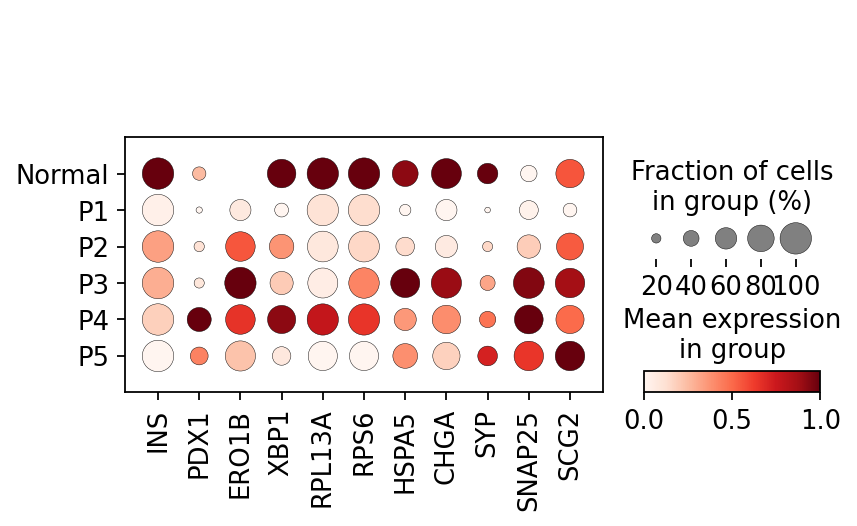

In [155]:
key_gene2 = [
    # canonical beta-cell function
    'INS',
    'PDX1',
    'ERO1B',
    'XBP1',

    # translation / ER burden
    'RPL13A',
    'RPS6',
    'HSPA5',

    # neuroendocrine communication
    'CHGA',
    'SYP',
    'SNAP25',
    'SCG2'
]
donor_str = adata_sub_final.obs['donor'].astype(str)

adata_sub_final.obs['donor2'] = donor_str.where(
    ~donor_str.str.startswith('HPAP'),
    'Normal'
)
sc.pl.dotplot(adata_sub_final,var_names=key_gene2,groupby='donor2',standard_scale='var',save='figure2d_full.pdf')